In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
import sys
# remove path from sys.path if it contains ".local"
sys.path = [p for p in sys.path if ".local" not in p]

In [3]:
import pickle
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import copy
import glob
import os

In [30]:
scalers_folder = "/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/notebooks/handcrafted_scalers"
regions = ["SAHARA", "INDIA", "CHINA", "BRAZIL"]

In [31]:
from gates.data.datasets import XarrayScaler, XarrayMinMaxScaler

In [32]:
# for each region, find all the scalers in the folder and load them in a dict
region_scalers = {}
for region in regions:
    region_scalers[region] = {}
    for scaler_file in glob.glob(os.path.join(scalers_folder, f"scalers_{region}_proper*")):
        with open(scaler_file, "rb") as f:
            scaler = pickle.load(f)
        region_scalers[region][os.path.basename(scaler_file)] = scaler
        break
    print(f"Region: {region}, Number of scalers: {len(region_scalers[region])}")

Region: SAHARA, Number of scalers: 1
Region: INDIA, Number of scalers: 1
Region: CHINA, Number of scalers: 1
Region: BRAZIL, Number of scalers: 1


In [31]:
region_scalers["SAHARA"]["scalers_SAHARA_proper_20260428_111328.pickle"]["inputs_scaler"].scalers

{('air_pressure', 3, 0): <gates.data.datasets.XarrayScaler at 0x7f762e395b20>,
 ('air_pressure', 3, 6): <gates.data.datasets.XarrayScaler at 0x7f762e395b20>,
 ('air_pressure', 3, 12): <gates.data.datasets.XarrayScaler at 0x7f762e395b20>,
 ('air_pressure', 9, 0): <gates.data.datasets.XarrayScaler at 0x7f762e395c70>,
 ('air_pressure', 9, 6): <gates.data.datasets.XarrayScaler at 0x7f762e395c70>,
 ('air_pressure', 9, 12): <gates.data.datasets.XarrayScaler at 0x7f762e395c70>,
 ('air_pressure', 15, 0): <gates.data.datasets.XarrayScaler at 0x7f762e3943e0>,
 ('air_pressure', 15, 6): <gates.data.datasets.XarrayScaler at 0x7f762e3943e0>,
 ('air_pressure',
  15,
  12): <gates.data.datasets.XarrayScaler at 0x7f762e3943e0>,
 ('air_pressure', 21, 0): <gates.data.datasets.XarrayScaler at 0x7f762e394e60>,
 ('air_pressure', 21, 6): <gates.data.datasets.XarrayScaler at 0x7f762e394e60>,
 ('air_pressure',
  21,
  12): <gates.data.datasets.XarrayScaler at 0x7f762e394e60>,
 ('air_pressure', 30, 0): <gates.d

In [27]:
scalers_dict = region_scalers["SAHARA"]["scalers_SAHARA_proper_20260428_111328.pickle"]["inputs_scaler"].scalers
for var in scalers_dict.keys():
    print(var)
    print(scalers_dict[var].params)


('air_pressure', 3, 0)
{'mean': array(95651.4, dtype=float32), 'std': array(3393.8665, dtype=float32)}
('air_pressure', 3, 6)
{'mean': array(95651.4, dtype=float32), 'std': array(3393.8665, dtype=float32)}
('air_pressure', 3, 12)
{'mean': array(95651.4, dtype=float32), 'std': array(3393.8665, dtype=float32)}
('air_pressure', 9, 0)
{'mean': array(89937.67, dtype=float32), 'std': array(2994.984, dtype=float32)}
('air_pressure', 9, 6)
{'mean': array(89937.67, dtype=float32), 'std': array(2994.984, dtype=float32)}
('air_pressure', 9, 12)
{'mean': array(89937.67, dtype=float32), 'std': array(2994.984, dtype=float32)}
('air_pressure', 15, 0)
{'mean': array(80050.96, dtype=float32), 'std': array(2372.806, dtype=float32)}
('air_pressure', 15, 6)
{'mean': array(80050.96, dtype=float32), 'std': array(2372.806, dtype=float32)}
('air_pressure', 15, 12)
{'mean': array(80050.96, dtype=float32), 'std': array(2372.806, dtype=float32)}
('air_pressure', 21, 0)
{'mean': array(67163.86, dtype=float32), 's

In [35]:
scaler_dict.items()

dict_items([('inputs_scaler', <gates.data.datasets.DefaultInputsScaler object at 0x7f762e3955b0>), ('fp_scaler', <gates.data.datasets.LogAndShiftFpScaler object at 0x7f762e396ea0>)])

In [33]:
import pandas as pd

rows = []

for region, scaler_files in region_scalers.items():
    for scaler_name, scaler_dict in scaler_files.items():
        scaler_key = "inputs_scaler"
        composite_scaler = scaler_dict[scaler_key]
        seen_vars = set()
        for (var_name, level, time_delta), scaler in composite_scaler.scalers.items():
            var_level = (var_name, level)
            if var_level in seen_vars:
                continue
            seen_vars.add(var_level)

            scaler_type = type(scaler).__name__
            params = scaler.params

            row = {
                "region": region,
                "scaler_name": scaler_name,
                "scaler_key": scaler_key,
                "scaler_type": scaler_type,
                "variable": var_name,
                "level": level,
                "mean": params.get("mean") if scaler_type == "XarrayScaler" else None,
                "std":  params.get("std")  if scaler_type == "XarrayScaler" else None,
                "min":  params.get("min")  if scaler_type == "XarrayMinMaxScaler" else None,
                "max":  params.get("max")  if scaler_type == "XarrayMinMaxScaler" else None,
            }
            rows.append(row)

df = pd.DataFrame(rows)
df


,region,scaler_name,scaler_key,scaler_type,variable,level,mean,std,min,max
0,SAHARA,scalers_SAHARA_proper_20260428_111328.pickle,inputs_scaler,XarrayScaler,air_pressure,3,95651.4,3393.8665,None,None
1,SAHARA,scalers_SAHARA_proper_20260428_111328.pickle,inputs_scaler,XarrayScaler,air_pressure,9,89937.67,2994.984,None,None
2,SAHARA,scalers_SAHARA_proper_20260428_111328.pickle,inputs_scaler,XarrayScaler,air_pressure,15,80050.96,2372.806,None,None
3,SAHARA,scalers_SAHARA_proper_20260428_111328.pickle,inputs_scaler,XarrayScaler,air_pressure,21,67163.86,1693.7463,None,None
4,SAHARA,scalers_SAHARA_proper_20260428_111328.pickle,inputs_scaler,XarrayScaler,air_pressure,30,45453.895,888.80206,None,None
...,...,...,...,...,...,...,...,...,...,...
243,BRAZIL,scalers_BRAZIL_proper_20260428_230038.pickle,inputs_scaler,XarrayScaler,y_wind,15,-0.7250199,5.0906405,None,None
244,BRAZIL,scalers_BRAZIL_proper_20260428_230038.pickle,inputs_scaler,XarrayScaler,y_wind,21,-0.66704524,4.940138,None,None
245,BRAZIL,scalers_BRAZIL_proper_20260428_230038.pickle,inputs_scaler,XarrayScaler,y_wind,30,0.18968175,5.947333,None,None
246,BRAZIL,scalers_BRAZIL_proper_20260428_230038.pickle,inputs_scaler,XarrayScaler,y_wind,42,1.4605033,10.762041,None,None


In [34]:
df[df["variable"]=="topog"]

,region,scaler_name,scaler_key,scaler_type,variable,level,mean,std,min,max
23,SAHARA,scalers_SAHARA_proper_20260428_111328.pickle,inputs_scaler,XarrayMinMaxScaler,topog,0,None,None,-170.70967,3042.907
85,INDIA,scalers_INDIA_proper_train_freq_2_test_freq_25...,inputs_scaler,XarrayMinMaxScaler,topog,0,None,None,-43.243484,5854.687
147,CHINA,scalers_CHINA_proper_20260428_093201.pickle,inputs_scaler,XarrayMinMaxScaler,topog,0,None,None,-136.68033,5912.0527
209,BRAZIL,scalers_BRAZIL_proper_20260428_230038.pickle,inputs_scaler,XarrayMinMaxScaler,topog,0,None,None,-160.04228,5061.7554


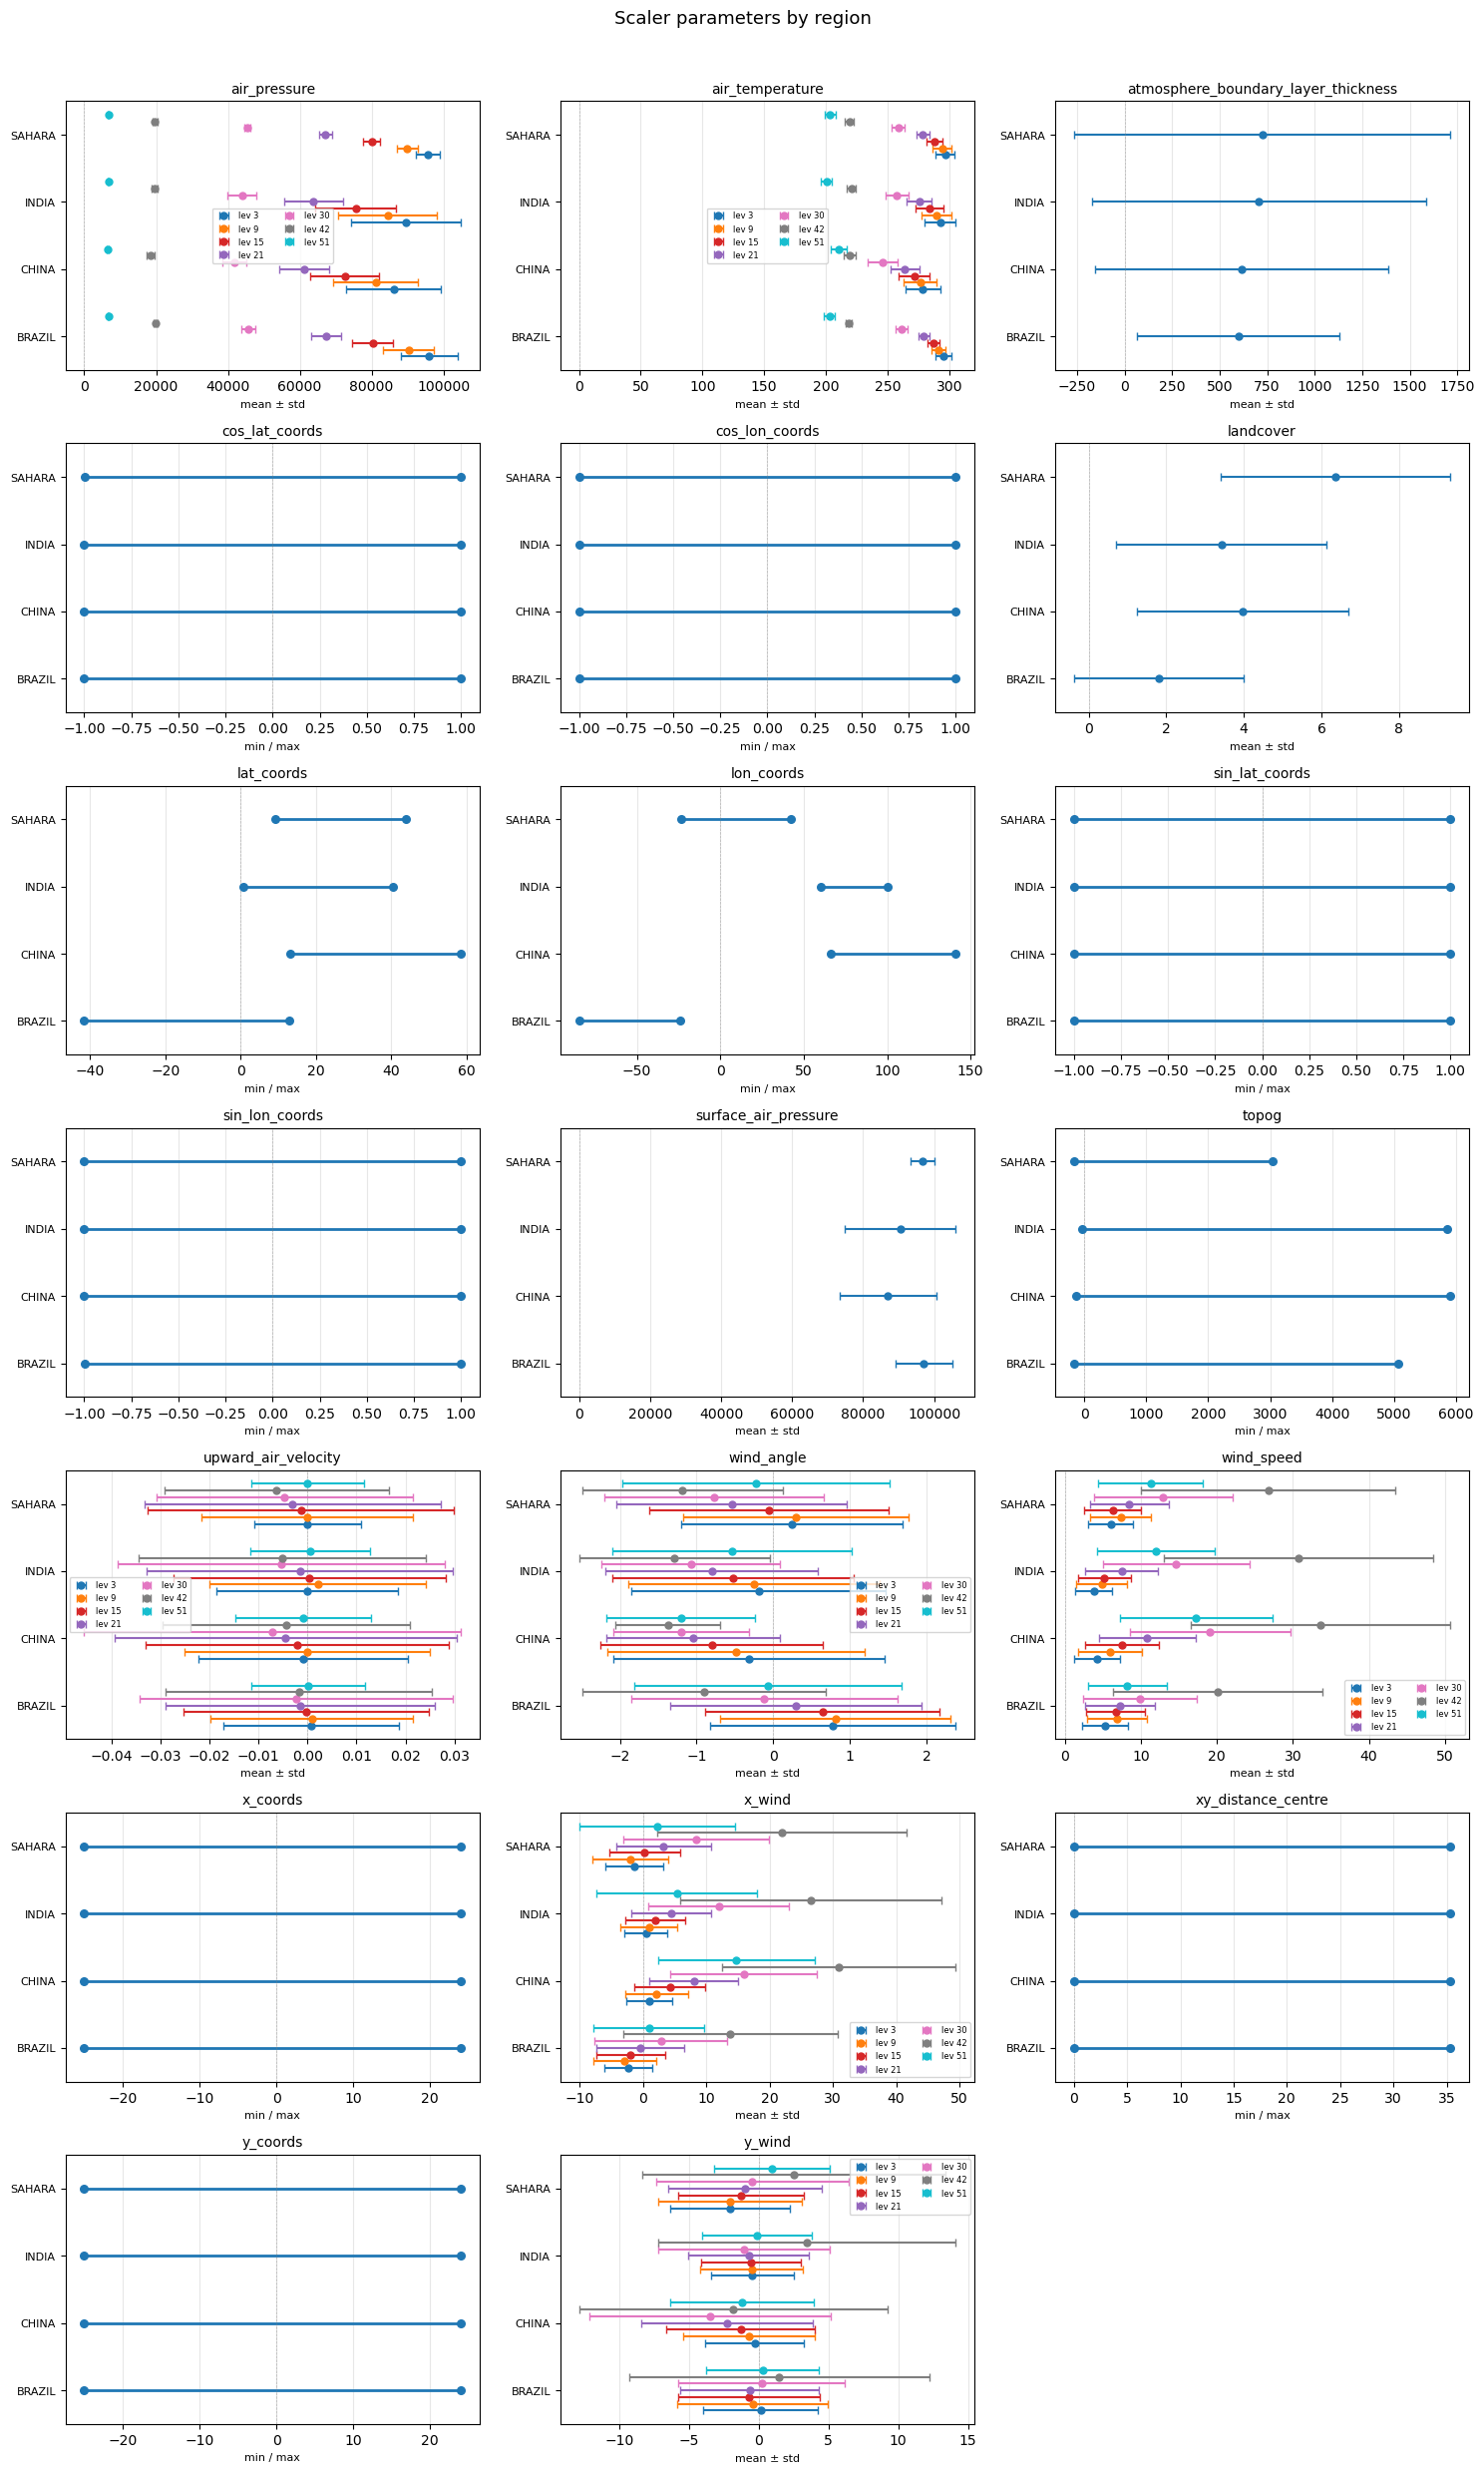

In [35]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Filter to one scaler_key if needed, e.g.:
# plot_df = df[df["scaler_key"] == "inputs_scaler"]
plot_df = df

regions = sorted(plot_df["region"].unique())
region_y = {r: i + 1 for i, r in enumerate(regions)}
variables = sorted(plot_df["variable"].unique())

n_cols = 3
n_rows = (len(variables) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).flatten()

for ax_idx, var in enumerate(variables):
    ax = axes[ax_idx]
    var_df = plot_df[plot_df["variable"] == var]

    levels = sorted(var_df["level"].unique())
    n_levels = len(levels)
    offsets = np.linspace(-0.3, 0.3, n_levels) if n_levels > 1 else [0.0]
    colors = cm.tab10(np.linspace(0, 0.9, n_levels))
    scaler_type = var_df["scaler_type"].iloc[0]

    for level, offset, color in zip(levels, offsets, colors):
        level_df = var_df[var_df["level"] == level]
        labeled = False

        for _, row in level_df.iterrows():
            y = region_y[row["region"]] + offset
            label = f"lev {level}" if not labeled else ""
            labeled = True

            if scaler_type == "XarrayScaler":
                ax.errorbar(
                    row["mean"], y, xerr=row["std"],
                    fmt="o", color=color, capsize=3,
                    markersize=5, label=label,
                )
            else:  # XarrayMinMaxScaler
                ax.plot([row["min"], row["max"]], [y, y], "-", color=color, lw=2)
                ax.scatter(
                    [row["min"], row["max"]], [y, y],
                    color=color, zorder=3, s=30,
                    label=label,
                )

    ax.set_yticks(list(region_y.values()))
    ax.set_yticklabels(list(region_y.keys()), fontsize=8)
    ax.set_ylim(0.5, len(regions) + 0.5)
    ax.set_title(var, fontsize=10)
    ax.set_xlabel("mean ± std" if scaler_type == "XarrayScaler" else "min / max", fontsize=8)
    ax.axvline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
    ax.grid(axis="x", alpha=0.3)
    if n_levels > 1:
        ax.legend(fontsize=6, ncol=2)

for ax_idx in range(len(variables), len(axes)):
    axes[ax_idx].set_visible(False)

plt.suptitle("Scaler parameters by region", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


In [36]:
param_cols = ["mean", "std", "min", "max"]

summary_df = (
    df
    .groupby(["variable", "level", "scaler_type", "scaler_key"])[param_cols]
    .mean()
    .reset_index()
)

summary_df


,variable,level,scaler_type,scaler_key,mean,std,min,max
0,air_pressure,3,XarrayScaler,inputs_scaler,91832.460938,9968.908203,NaN,NaN
1,air_pressure,9,XarrayScaler,inputs_scaler,86432.765625,8928.241211,NaN,NaN
2,air_pressure,15,XarrayScaler,inputs_scaler,77073.90625,7226.431641,NaN,NaN
3,air_pressure,21,XarrayScaler,inputs_scaler,64856.625,5224.981445,NaN,NaN
4,air_pressure,30,XarrayScaler,inputs_scaler,44192.378906,2515.25,NaN,NaN
...,...,...,...,...,...,...,...,...
57,y_wind,15,XarrayScaler,inputs_scaler,-0.980903,4.624477,NaN,NaN
58,y_wind,21,XarrayScaler,inputs_scaler,-1.169145,5.226176,NaN,NaN
59,y_wind,30,XarrayScaler,inputs_scaler,-1.205738,6.908753,NaN,NaN
60,y_wind,42,XarrayScaler,inputs_scaler,1.393954,10.843582,NaN,NaN


In [37]:
summary_df[df.variable=="x_wind"]

/tmp/ipykernel_2708491/207055855.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  summary_df[df.variable=="x_wind"]


,variable,level,scaler_type,scaler_key,mean,std,min,max
46,x_wind,3,XarrayScaler,inputs_scaler,-0.529079,3.833341,NaN,NaN
47,x_wind,9,XarrayScaler,inputs_scaler,-0.43553,5.100252,NaN,NaN
48,x_wind,15,XarrayScaler,inputs_scaler,1.150173,5.374537,NaN,NaN
49,x_wind,21,XarrayScaler,inputs_scaler,3.853361,6.962059,NaN,NaN
50,x_wind,30,XarrayScaler,inputs_scaler,9.789316,11.184052,NaN,NaN
51,x_wind,42,XarrayScaler,inputs_scaler,23.336676,18.905565,NaN,NaN
52,x_wind,51,XarrayScaler,inputs_scaler,5.814693,11.525125,NaN,NaN


In [21]:
zero_mean_vars = {"upward_air_velocity", "wind_angle", "y_wind", "x_wind"}  # variables where 0 is physically meaningful

rows = []
for (var, level, scaler_key), group in summary_df.groupby(["variable", "level", "scaler_key"]):
    row = {"variable": var, "level": level, "scaler_key": scaler_key}
    
    if var in zero_mean_vars:
        # std around zero: rms = sqrt(mean² + std²), then average across regions
        region_rms = (group["mean"] ** 2 + group["std"] ** 2) ** 0.5
        row["forced_mean"] = 0.0
        row["forced_std"]  = region_rms.mean()
    else:
        row["forced_mean"] = group["mean"].mean()
        row["forced_std"]  = group["std"].mean()
    
    rows.append(row)

coherent_df = pd.DataFrame(rows)
coherent_df

,variable,level,scaler_key,forced_mean,forced_std
0,air_pressure,3,inputs_scaler,91832.460938,9968.908203
1,air_pressure,9,inputs_scaler,86432.765625,8928.241211
2,air_pressure,15,inputs_scaler,77073.906250,7226.431641
3,air_pressure,21,inputs_scaler,64856.625000,5224.981445
4,air_pressure,30,inputs_scaler,44192.378906,2515.250000
...,...,...,...,...,...
57,y_wind,15,inputs_scaler,0.000000,4.727363
58,y_wind,21,inputs_scaler,0.000000,5.355354
59,y_wind,30,inputs_scaler,0.000000,7.013178
60,y_wind,42,inputs_scaler,0.000000,10.932812


## data loading

In [4]:
import sys
import os
sys.path


['/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python312.zip',
 '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12',
 '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12/lib-dynload',
 '',
 '__editable__.openghg_inversions-0.2.0.finder.__path_hook__',
 '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12/site-packages']

In [5]:
os.environ["PYTHONNOUSERSITE"] = "1"
os.environ["PATH"] = ":".join(
    p for p in os.environ["PATH"].split(":") if ".local" not in p
)
os.environ["CONDA_PYTHON_EXE"] = "/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/bin/python"

In [6]:
from dask.distributed import Client, LocalCluster

#worker_env = {**os.environ, "PYTHONNOUSERSITE": "1"}

# Create a cluster using all available CPUs on the node
cluster = LocalCluster(
    n_workers=4,          # match --cpus-per-task
    threads_per_worker=1,  # 1 thread per worker avoids GIL issues with NumPy
    memory_limit='2GB'
)

2026-06-12 16:20:04,256 - distributed.worker - WARNING - Mismatched versions found

+---------+---------------------------------------------+-----------+---------+
| Package | Worker-0db17a2e-6ce4-4e76-a1c4-22f92f520a7f | Scheduler | Workers |
+---------+---------------------------------------------+-----------+---------+
| msgpack | 1.1.2                                       | 1.1.0     | 1.1.2   |
+---------+---------------------------------------------+-----------+---------+
2026-06-12 16:20:04,281 - distributed.worker - WARNING - Mismatched versions found

+---------+---------------------------------------------+-----------+---------+
| Package | Worker-c1183439-f35a-4365-9a3f-c1dc7d8ce982 | Scheduler | Workers |
+---------+---------------------------------------------+-----------+---------+
| msgpack | 1.1.2                                       | 1.1.0     | 1.1.2   |
+---------+---------------------------------------------+-----------+---------+
2026-06-12 16:20:04,302 - distri

2026-06-12 16:30:29,343 - distributed.dashboard.components.scheduler - ERROR - Circle(id='p31071', ...).radius doesn't have a value set
Traceback (most recent call last):
  File "/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12/site-packages/distributed/utils.py", line 838, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12/site-packages/distributed/dashboard/components/scheduler.py", line 4822, in profile_doc
    doc.add_root(prof.root)
  File "/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12/site-packages/bokeh/document/document.py", line 338, in add_root
    with self.models.freeze():
         ^^^^^^^^^^^^^^^^^^^^
  File "/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12/contextlib.py", line 144, in __exit__
    next(self.gen)
  File "/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_

In [7]:
client = Client(cluster)
# 3. Check workers are responsive
client.run(lambda: "ok")  # should return {'tcp://...': 'ok'} for each worker

/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12/site-packages/distributed/client.py:1393: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| msgpack | 1.1.0  | 1.1.0     | 1.1.2   |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


{'tcp://127.0.0.1:34945': 'ok',
 'tcp://127.0.0.1:35895': 'ok',
 'tcp://127.0.0.1:37475': 'ok',
 'tcp://127.0.0.1:44481': 'ok'}

In [8]:
print(client.dashboard_link)  # usually http://127.0.0.1:8787/status

http://127.0.0.1:8787/status


In [9]:
from gates.training.training_helperfuns import load_parameter_file
#import gates
from gates.config import get_config
import gates.training.training as gates_training
from gates import LoadSquareSatelliteData

/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_gates_env/lib/python3.12/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [ ]:
cfg = get_config()
file_path = cfg.parameter_files_dir

In [ ]:
parameter_path = "NEW_parameter_template_terminal.json"

In [28]:
data2 = LoadSquareSatelliteData(2016, month="06", freq=20, size=50, region="BRAZIL", verbose=True, fill_outofdomain_with="nans", met_args={"met_levels":[3,15,30]})#, 9, 15, 21, 30, 42, 51]})

2024.5.0
---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201606*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 20
Loading 95 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 50
Padding lon by (0, 1) cells (W, E) with mode='nans'

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201606*.nc
WITH CHUNKING - met
Met file chunk stats:
Chunks: Frozen({'model_level_number': (3,), 'lat': (357,), 'lon': (239,), 'time': (8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8)})
Dataset size (GB): 4.668885124

---- LOADING TOPOG AND LANDCOVER
Loading topography from /group/chem/acrg/LPDM/topog_NAME/Top

In [10]:
data = LoadSquareSatelliteData(2016, month="06", freq=50, size=50, region="SAHARA", verbose=True, fill_outofdomain_with="nans", met_args={"met_levels":[3,15,30]})#, 9, 15, 21, 30, 42, 51]})

2024.5.0
---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_201606*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 50
Loading 22 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 50
Padding lat by (0, 3) cells (S, N) with mode='nans'

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/NORTHAFRICA/NORTHAFRICA_Met_201606*.nc
WITH CHUNKING - met
Met file chunk stats:
Chunks: Frozen({'model_level_number': (3,), 'lat': (296,), 'lon': (320,), 'time': (8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8)})
Dataset size (GB): 1.636768484

---- LOADING TOPOG AND LANDCOVER
Loading topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
Loading landcover from /group/chem/acrg/LPDM/topog_NAME/land_cover.nc
loading both into memory
----- Cutting topog
----- Cutting met
Graph build: 0.00s
met_unique h

In [11]:
input_variables = {
        "met_variables":["x_wind", "y_wind", "upward_air_velocity", "atmosphere_boundary_layer_thickness", "surface_air_pressure", "air_temperature", "air_pressure", "wind_speed", "wind_angle"],
        "met_levels":[3,15,30],#, 9, 15, 21, 30, 42, 51],
        "static_variables":["lat_coords", "lon_coords", "x_coords", "y_coords", "xy_distance_centre", "topog", "landcover"], 
        "time_deltas":[],
        "add_wind_direction":True,
        "load_into_memory": True
        
    }

In [12]:
from gates.data.datasets import get_square_satellite_inputs_v2

In [ ]:
inputs2, data2 = get_square_satellite_inputs_v2(data2, **input_variables, verbose=True)

In [14]:
inputs, data = get_square_satellite_inputs_v2(data, **input_variables, verbose=True)

------------------------
---EXTRACTING MET DATA (v2)---
Time deltas: [0]
Met variables: ['x_wind', 'y_wind', 'upward_air_velocity', 'atmosphere_boundary_layer_thickness', 'surface_air_pressure', 'air_temperature', 'air_pressure', 'wind_speed', 'wind_angle']
Met levels: [3, 15, 30]
Selecting 22 unique met timestamps 
First few unique timestamps: [numpy.datetime64('2016-06-01T12:00:00.000000000'), numpy.datetime64('2016-06-02T12:00:00.000000000'), numpy.datetime64('2016-06-04T12:00:00.000000000')] ...
Loading selected met data into memory...
Setting up met_with_levels: ['air_pressure', 'air_temperature', 'upward_air_velocity', 'x_wind', 'y_wind', 'wind_angle', 'wind_speed']
Setting up surface_met: ['atmosphere_boundary_layer_thickness', 'surface_air_pressure']
Setting up static: ['lat_coords', 'lon_coords', 'y_coords', 'x_coords', 'xy_distance_centre', 'topog', 'landcover']
loading stadcked static into memory


In [15]:
import gates.data.datasets as gates_datasets

In [41]:
scaler_file = "/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/gates/data/handcrafted_scaler_test_clean.json"

In [17]:
input_scaler

In [58]:
inputs_dataset = gates_datasets.InputsDataset(inputs, scaler=gates_datasets.HandcraftedInputsScaler, scaler_params={ "verbose": True, "stats_file": scaler_file }, verbose=True )
inputs_dataset.fit()
inputs_scaled = inputs_dataset.transform(inputs)

Setting up standard scaler for ('air_pressure', 3, 0)
Setting up standard scaler for ('air_pressure', 15, 0)
Setting up standard scaler for ('air_pressure', 30, 0)
Setting up standard scaler for ('air_temperature', 3, 0)
Setting up standard scaler for ('air_temperature', 15, 0)
Setting up standard scaler for ('air_temperature', 30, 0)
Setting up standard scaler for ('upward_air_velocity', 3, 0)
Setting up standard scaler for ('upward_air_velocity', 15, 0)
Setting up standard scaler for ('upward_air_velocity', 30, 0)
Setting up standard scaler for ('x_wind', 3, 0)
Setting up standard scaler for ('x_wind', 15, 0)
Setting up standard scaler for ('x_wind', 30, 0)
Setting up standard scaler for ('y_wind', 3, 0)
Setting up standard scaler for ('y_wind', 15, 0)
Setting up standard scaler for ('y_wind', 30, 0)
Setting up standard scaler for ('wind_angle', 3, 0)
Setting up standard scaler for ('wind_angle', 15, 0)
Setting up standard scaler for ('wind_angle', 30, 0)
Setting up minmax scaler for

In [22]:
inputs_dataset = gates_datasets.InputsDataset(inputs, scaler=gates_datasets.DefaultInputsScaler, scaler_params={ "verbose": True}, verbose=True )
inputs_dataset.fit()
inputs_scaled = inputs_dataset.transform(inputs)

fitting standardise scaler for var air_pressure
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler...
      at level 30
Computing mean and std for scaler...
fitting standardise scaler for var air_temperature
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler...
      at level 30
Computing mean and std for scaler...
fitting standardise scaler for var upward_air_velocity
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler...
      at level 30
Computing mean and std for scaler...
fitting standardise scaler for var x_wind
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler...
      at level 30
Computing mean and std for scaler...
fitting standardise scaler for var y_wind
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler.

In [13]:
inputs.variable_name

<xarray.DataArray 'variable_name' (variable_name: 30)> Size: 240B
array([('air_pressure', 3, 0), ('air_pressure', 15, 0),
       ('air_pressure', 30, 0), ('air_temperature', 3, 0),
       ('air_temperature', 15, 0), ('air_temperature', 30, 0),
       ('upward_air_velocity', 3, 0), ('upward_air_velocity', 15, 0),
       ('upward_air_velocity', 30, 0), ('x_wind', 3, 0), ('x_wind', 15, 0),
       ('x_wind', 30, 0), ('y_wind', 3, 0), ('y_wind', 15, 0),
       ('y_wind', 30, 0), ('wind_angle', 3, 0), ('wind_angle', 15, 0),
       ('wind_angle', 30, 0), ('wind_speed', 3, 0), ('wind_speed', 15, 0),
       ('wind_speed', 30, 0), ('atmosphere_boundary_layer_thickness', 0, 0),
       ('surface_air_pressure', 0, 0), ('lat_coords', 0, 0),
       ('lon_coords', 0, 0), ('y_coords', 0, 0), ('x_coords', 0, 0),
       ('xy_distance_centre', 0, 0), ('topog', 0, 0), ('landcover', 0, 0)],
      dtype=object)
Coordinates:
  * variable_name  (variable_name) object 240B MultiIndex
  * variable       (variable_name) object 240B 'air_pressure' ... 'landcover'
  * levels         (variable_name) int64 240B 3 15 30 3 15 30 3 ... 0 0 0 0 0 0
  * time_delta     (variable_name) int64 240B 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


In [21]:
def plot_input_hists(inputs, suptitle=None):
    # Group variable_name tuples by base name
    groups = defaultdict(list)
    for var in inputs.variable_name.values:
        base_name = var[0]
        groups[base_name].append(var)

    n_groups = len(groups)
    ncols = 4
    nrows = int(np.ceil(n_groups / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = axes.flatten()

    for i, (base_name, members) in enumerate(groups.items()):
        ax = axes[i]
        for var in members:
            data = inputs.sel(variable_name=var).values.ravel()
            label = f'level {var[1]}'
            ax.hist(data, bins=50, alpha=0.4, edgecolor='none', label=label)
        ax.set_title(base_name)
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')
        ax.legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    if suptitle:
        plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout()
    plt.show()



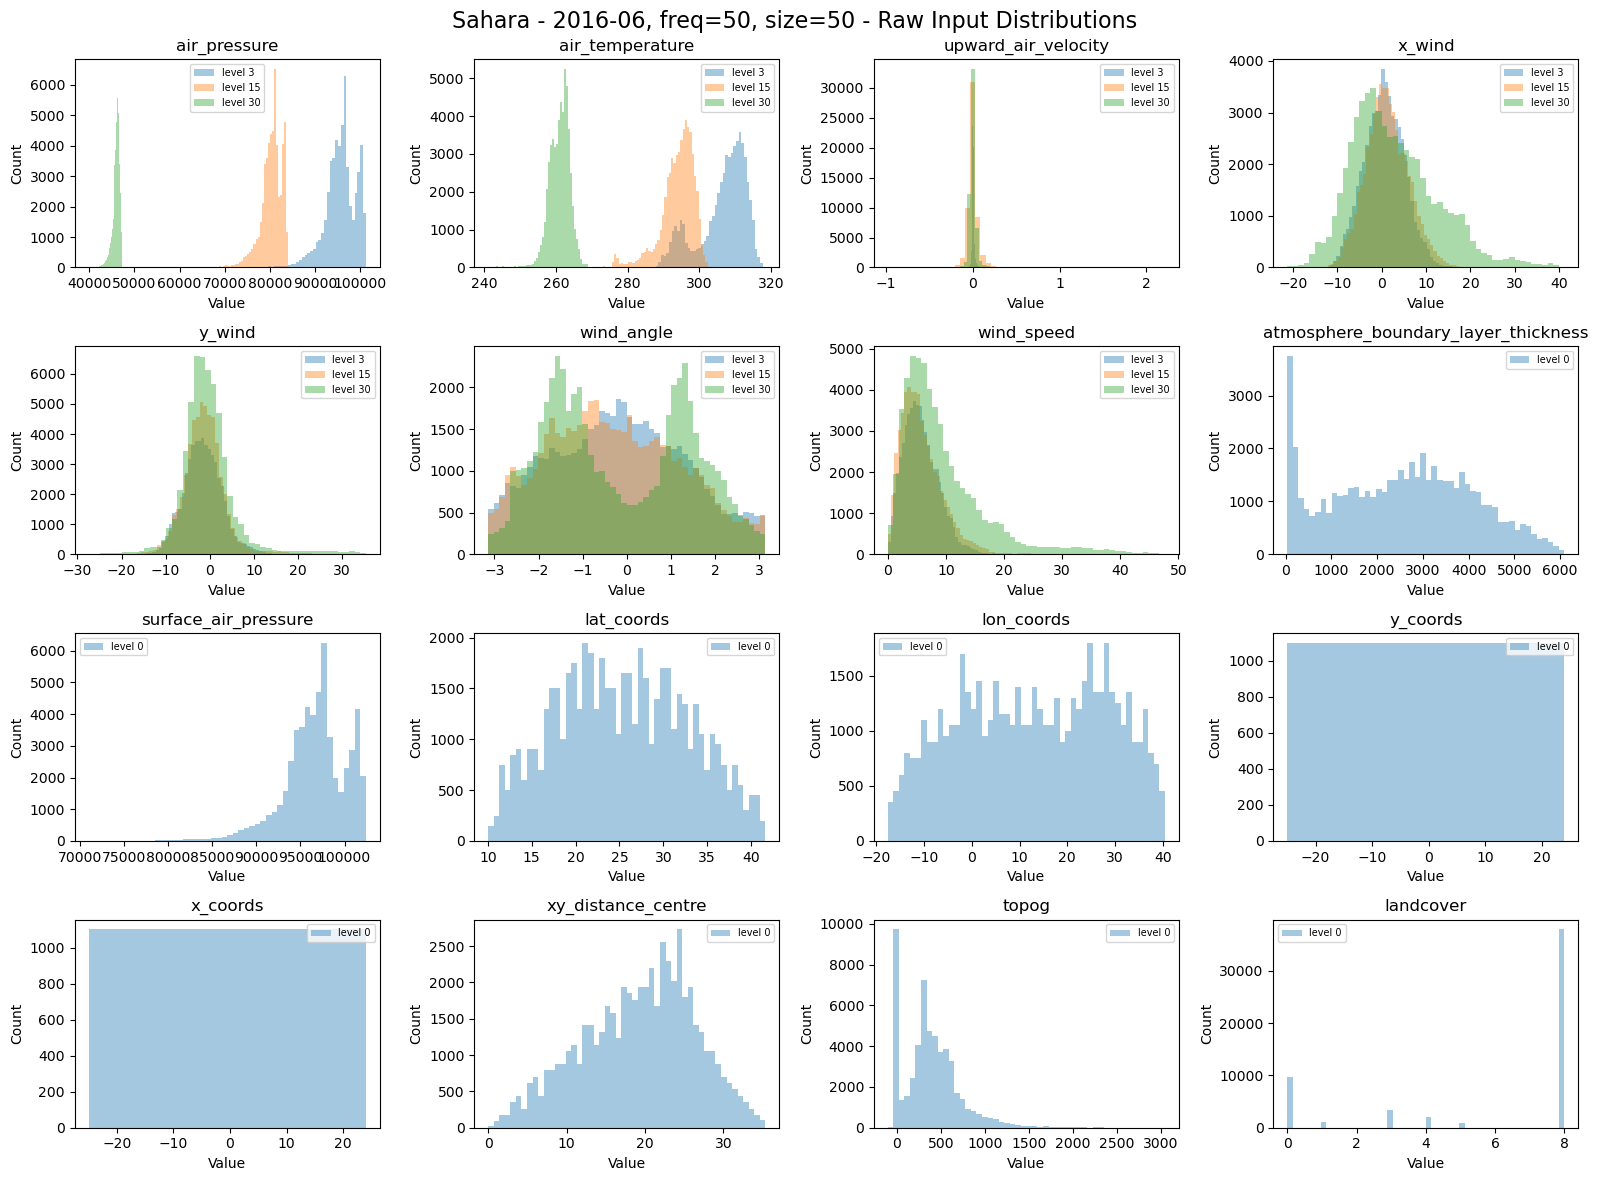

In [17]:
plot_input_hists(inputs, suptitle="Sahara - 2016-06, freq=50, size=50 - Raw Input Distributions")

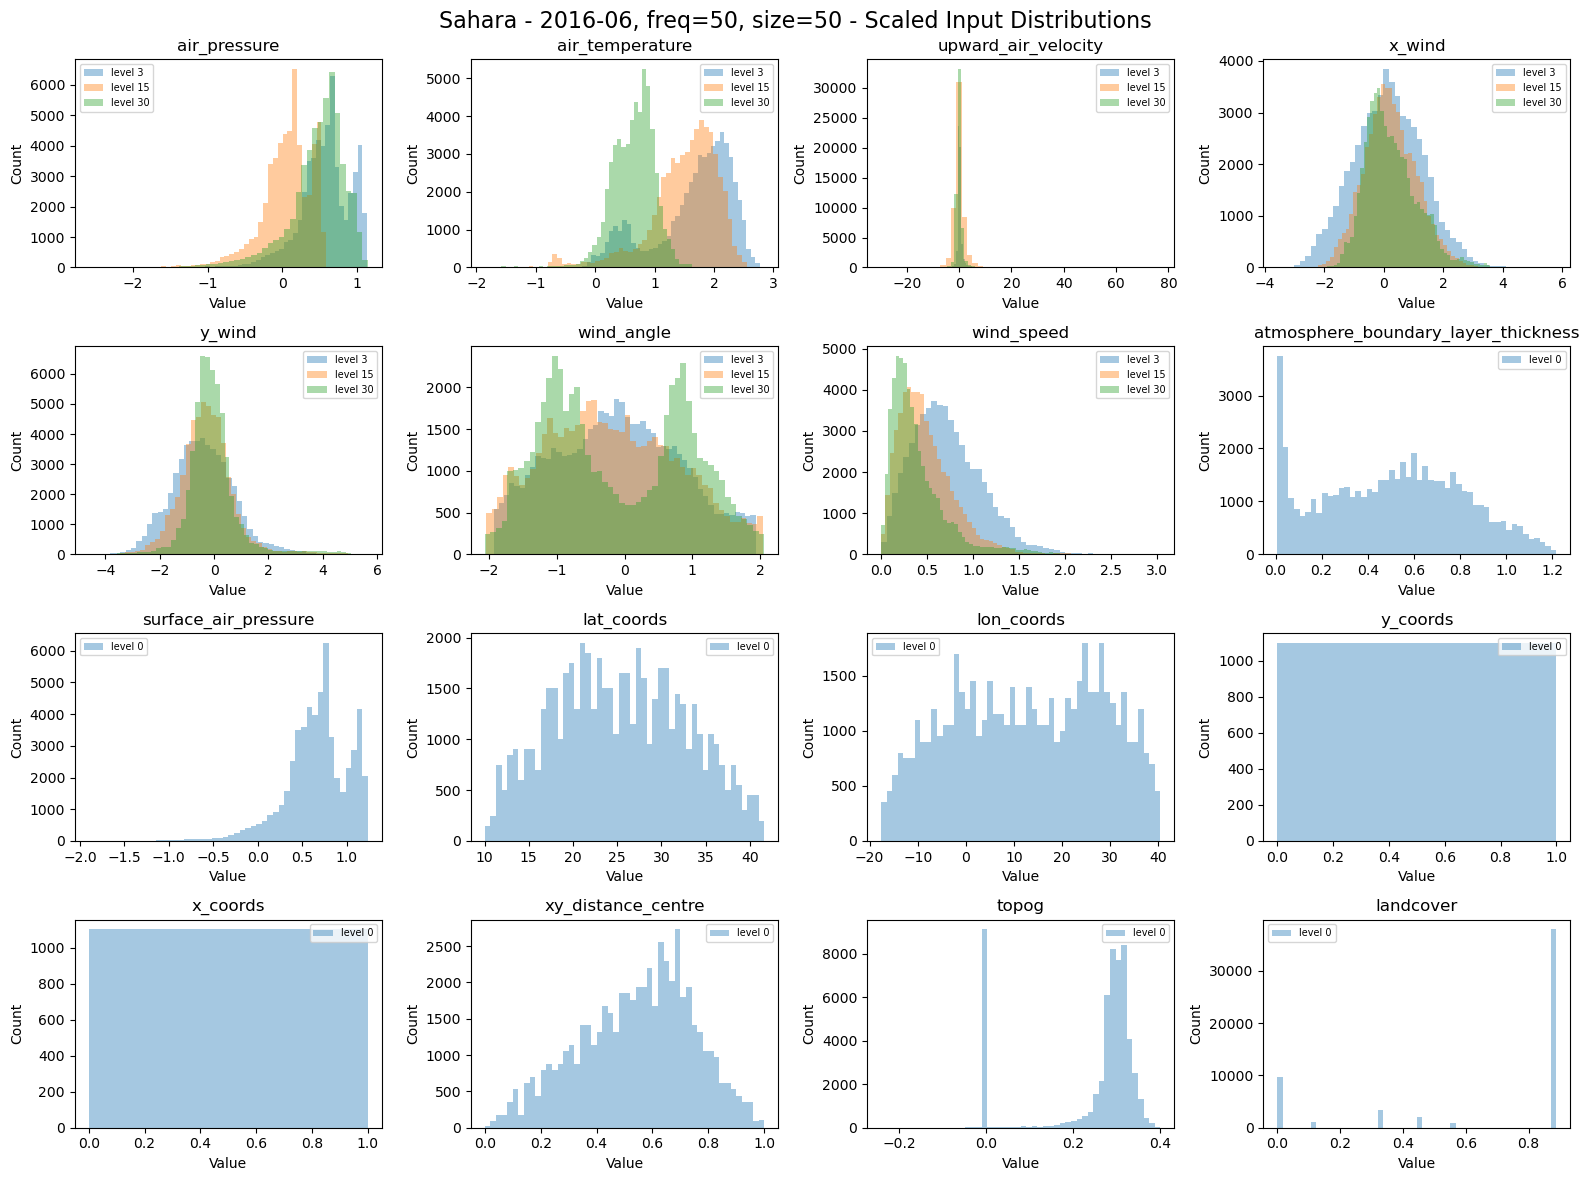

In [57]:
plot_input_hists(inputs_scaled, suptitle="Sahara - 2016-06, freq=50, size=50 - Scaled Input Distributions")

(array([8.994e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.700e+01,
        8.000e+01, 4.050e+02, 5.685e+03, 3.972e+04]),
 array([-8.00000095, -6.85167217, -5.70334291, -4.55501413, -3.40668511,
        -2.25835609, -1.11002707,  0.03830185,  1.18663085,  2.33495975,
         3.48328876]),
 <BarContainer object of 10 artists>)

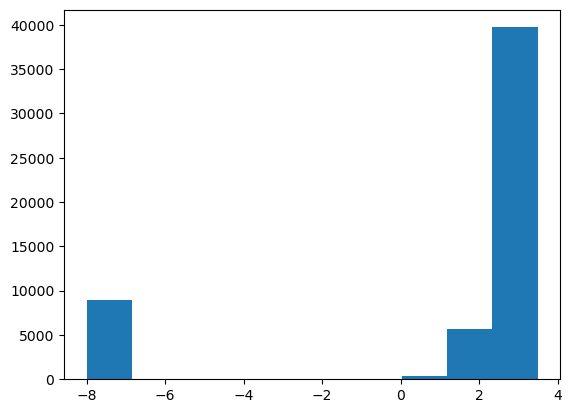

In [51]:
plt.hist(np.log10(1e-8+inputs.sel(variable_name=("topog", 0,0))).values.flatten())

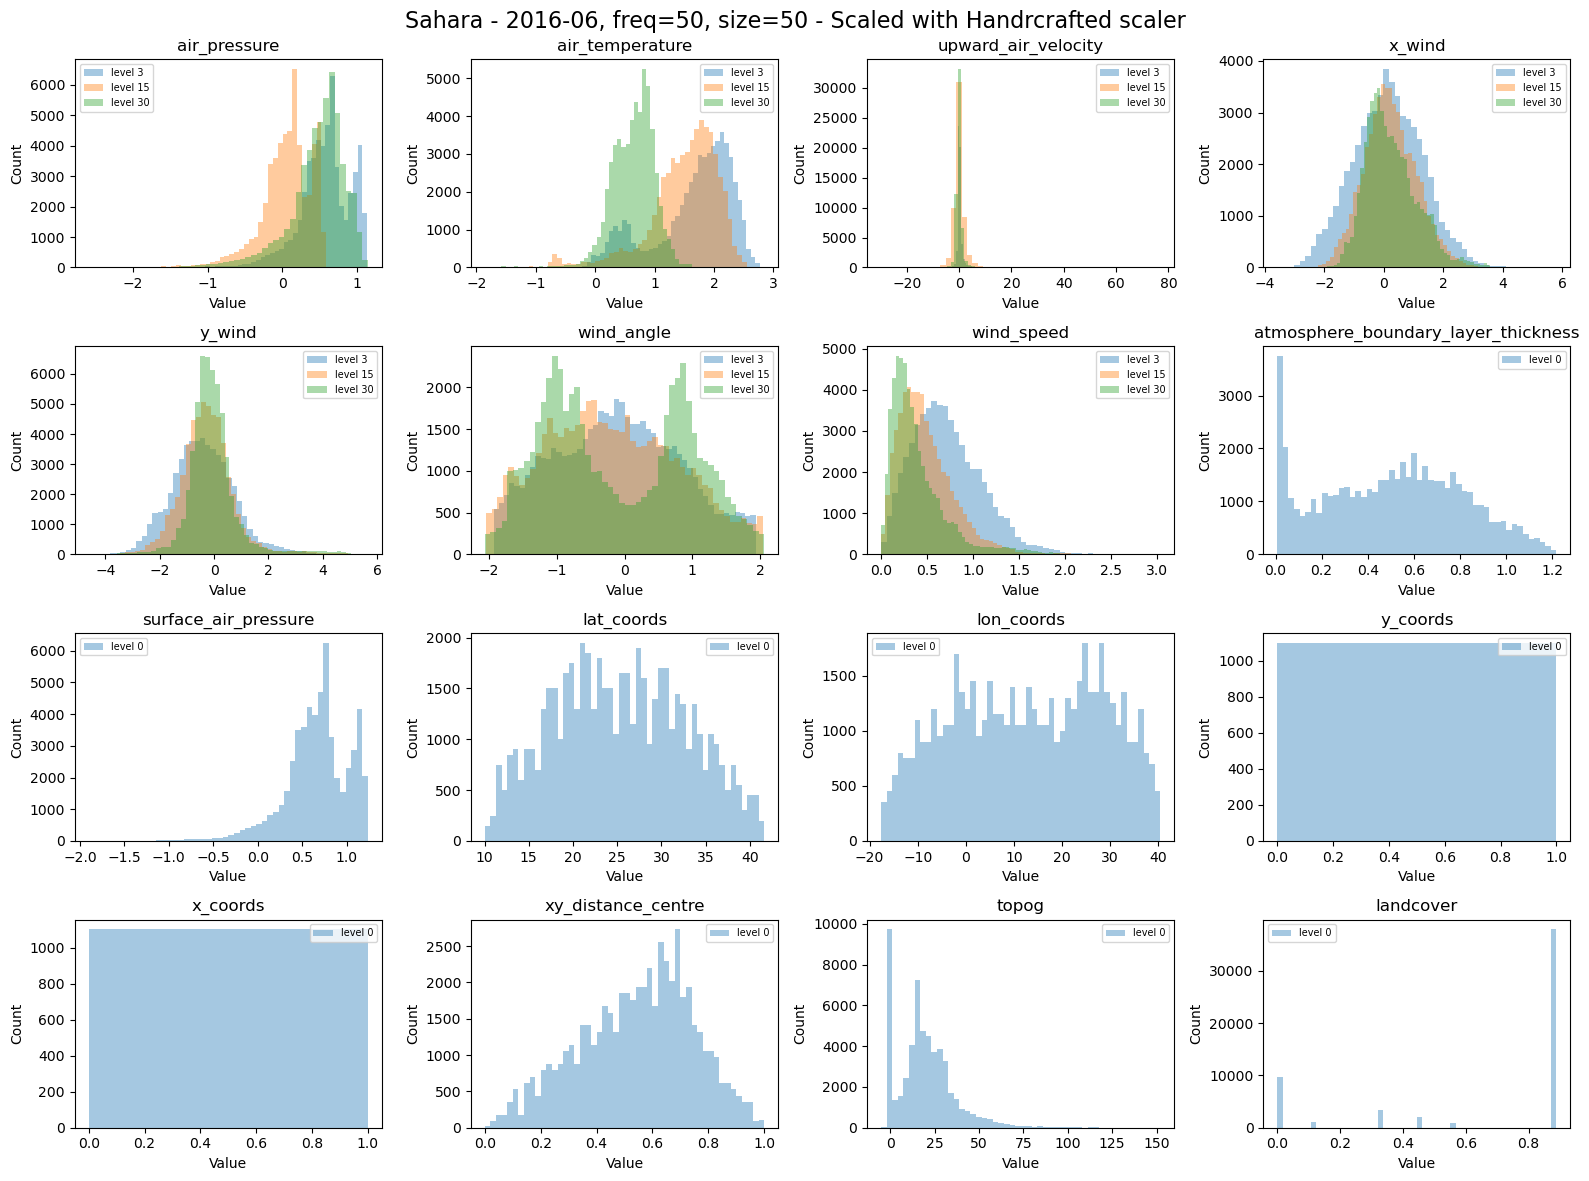

In [59]:
plot_input_hists(inputs_scaled, suptitle="Sahara - 2016-06, freq=50, size=50 - Scaled with Handrcrafted scaler")

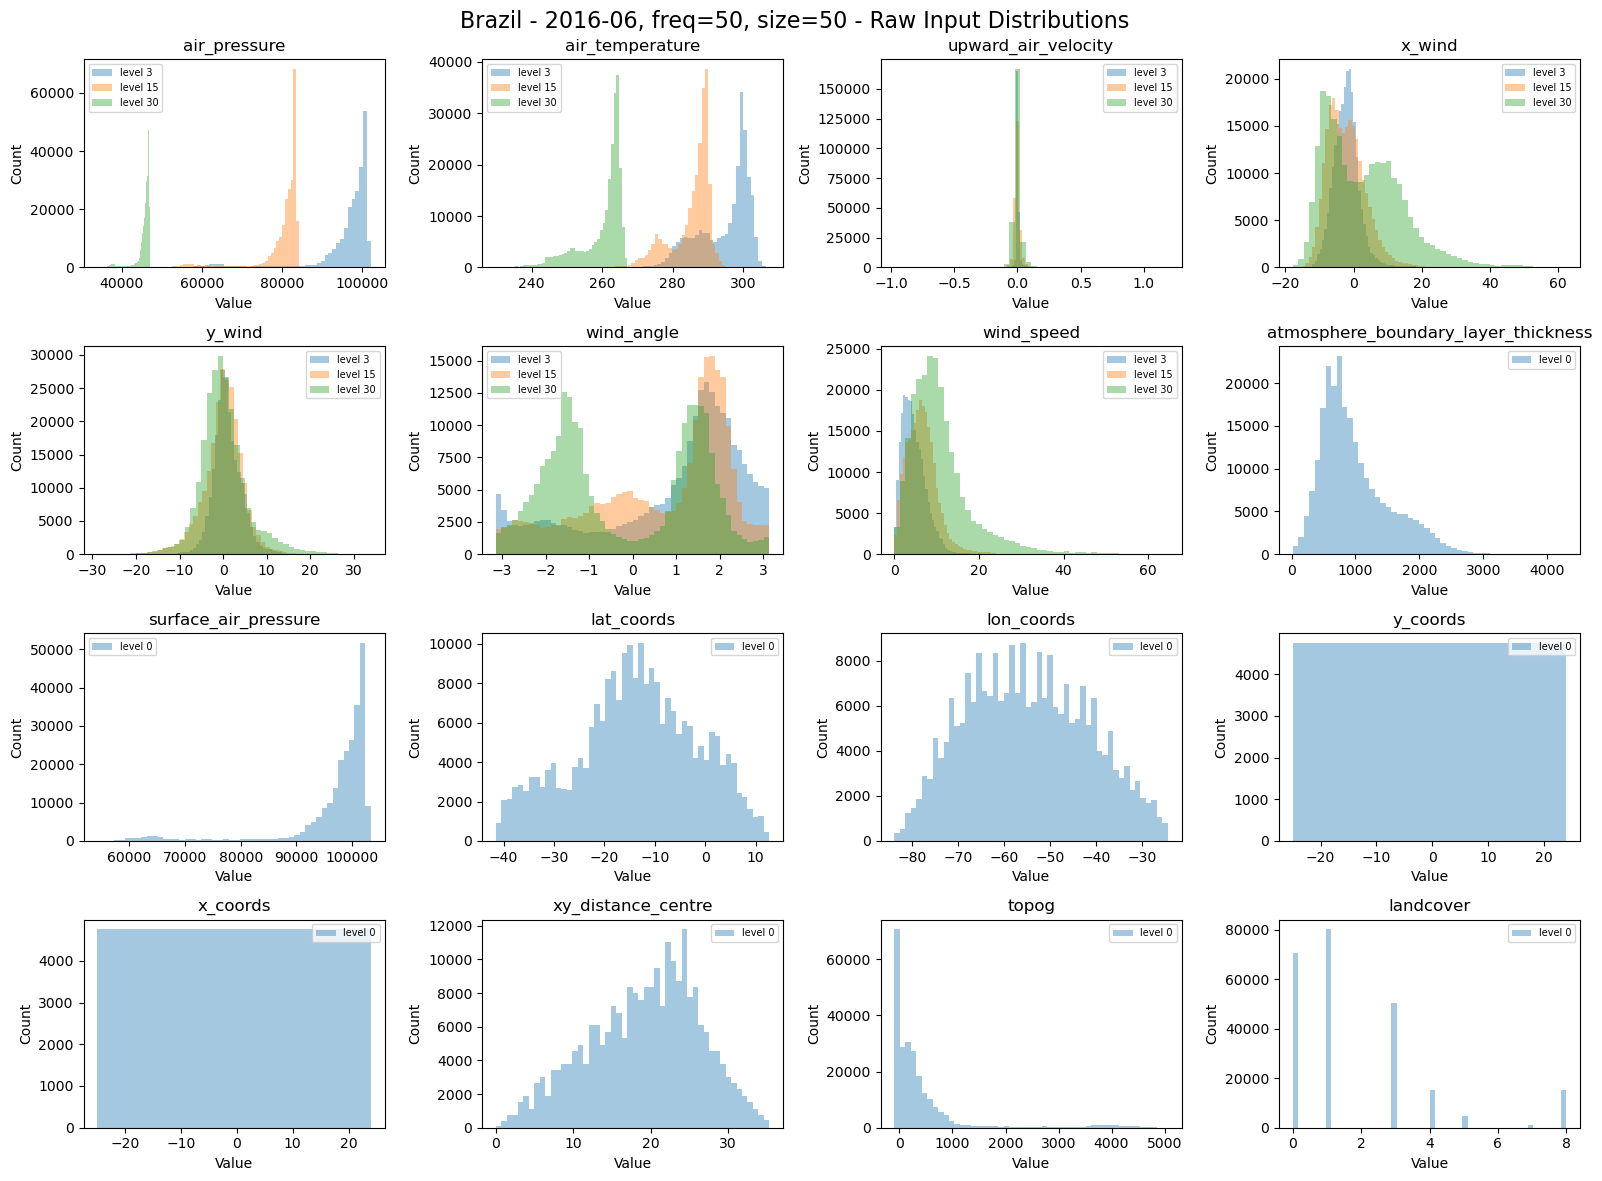

In [30]:
plot_input_hists(inputs2, suptitle="Brazil - 2016-06, freq=50, size=50 - Raw Input Distributions")

In [31]:
inputs_dataset2 = gates_datasets.InputsDataset(inputs2, scaler=gates_datasets.DefaultInputsScaler, scaler_params={ "verbose": True}, verbose=True )
inputs_dataset2.fit()
inputs_scaled2 = inputs_dataset2.transform(inputs2)

fitting standardise scaler for var air_pressure
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler...
      at level 30
Computing mean and std for scaler...
fitting standardise scaler for var air_temperature
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler...
      at level 30
Computing mean and std for scaler...
fitting standardise scaler for var upward_air_velocity
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler...
      at level 30
Computing mean and std for scaler...
fitting standardise scaler for var x_wind
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler...
      at level 30
Computing mean and std for scaler...
fitting standardise scaler for var y_wind
      at level 3
Computing mean and std for scaler...
      at level 15
Computing mean and std for scaler.

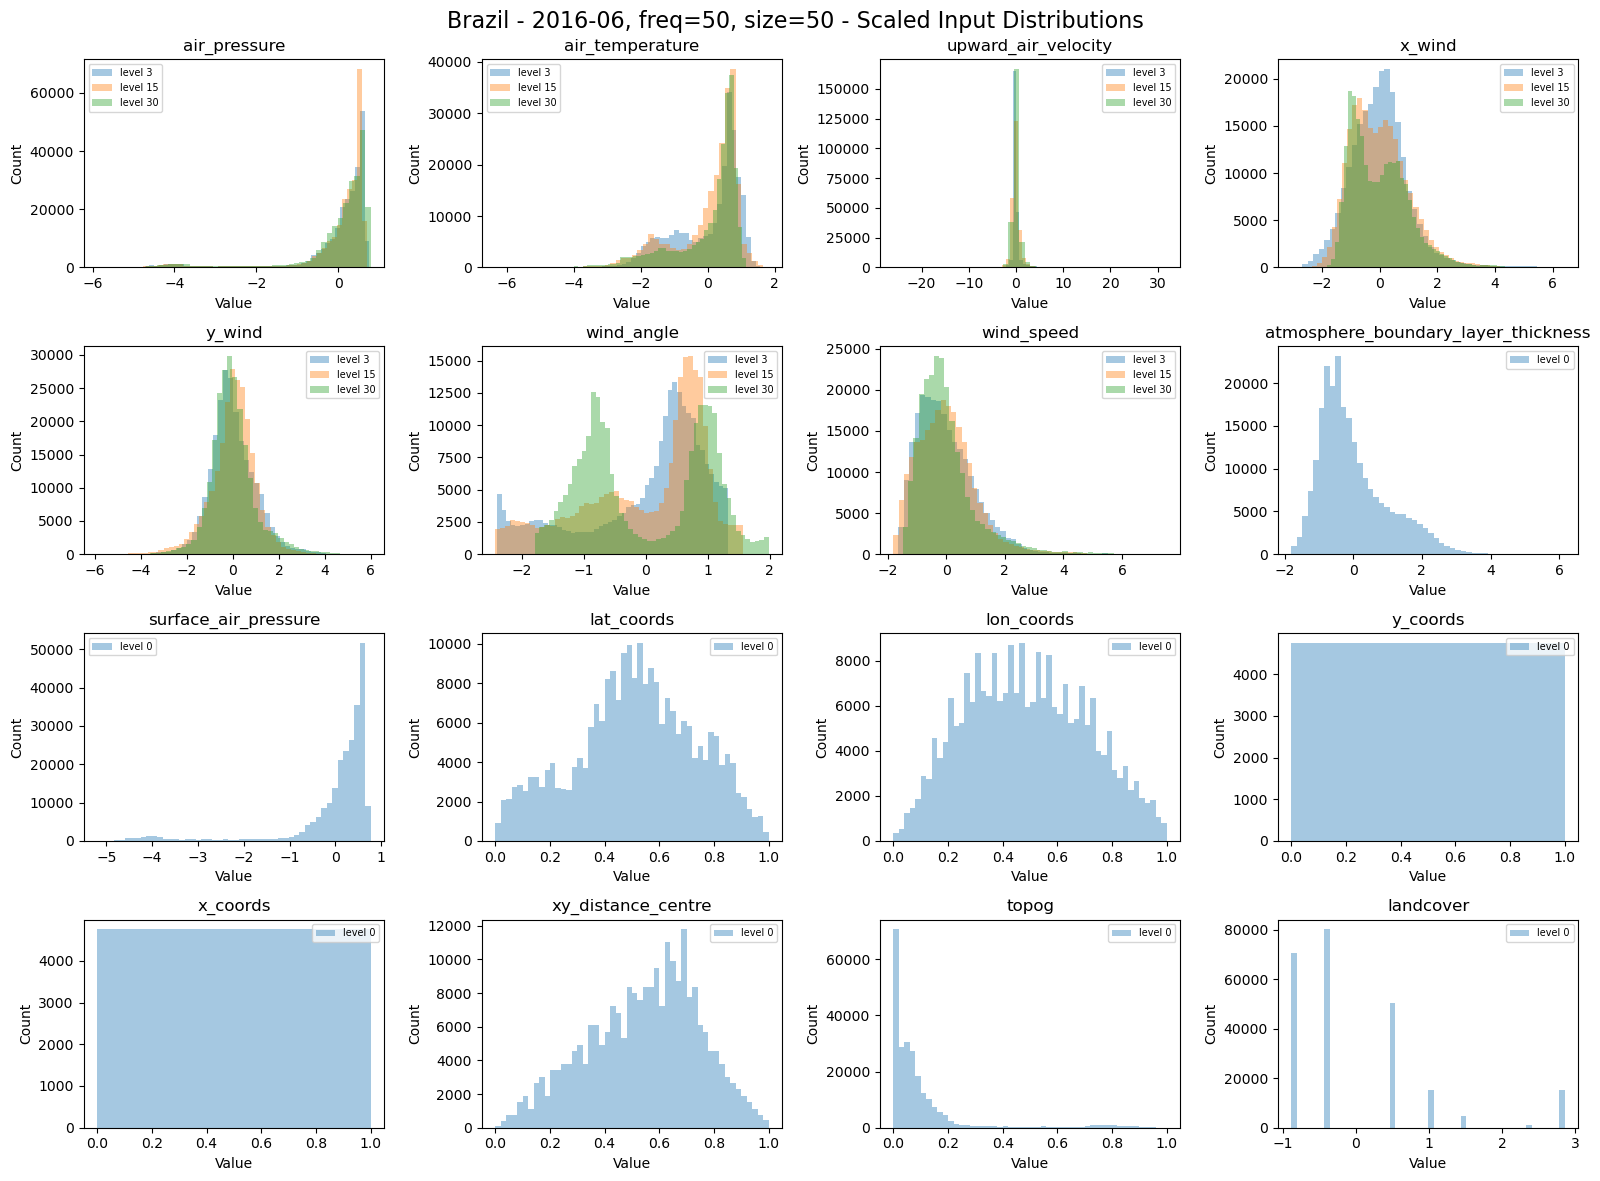

In [33]:
plot_input_hists(inputs_scaled2, suptitle="Brazil - 2016-06, freq=50, size=50 - Scaled Input Distributions")